In [1]:
import pickle

PREPROCESSED_PATH = "/media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/gnn_preprocessed.pkl"

with open(PREPROCESSED_PATH, "rb") as f:
    pre = pickle.load(f)

# Unpack everything
data_filled  = pre["data_filled"]
flagged      = pre["flagged"]
dates        = pre["dates"]
stations     = pre["stations"]
feature_cols = pre["feature_cols"]
edge_index   = pre["edge_index"]
edge_attr    = pre["edge_attr"]
scalers      = pre["scalers"]
rh_idx       = pre["rh_idx"]
config       = pre["config"]

T, N, F = data_filled.shape

print("Loaded successfully")
print(f"  data_filled shape : {data_filled.shape}")
print(f"  flagged days      : {flagged.sum():,} / {T:,}")
print(f"  config            : {config}")

Loaded successfully
  data_filled shape : (10897, 34, 46)
  flagged days      : 2,151 / 10,897
  config            : {'window_size': 7, 'skip_threshold': 0.3, 'min_bad_stations': 3, 'core_features': ['TG', 'TN', 'TX', 'UG', 'RH', 'FG', 'Q']}


In [2]:
import torch

# We build sample i=100 manually so we can see exactly what shape the model receives
i           = 100
WINDOW_SIZE = config["window_size"]   # 7

start = i
end   = i + WINDOW_SIZE   # target day index

print(f"Input window : day {start} to day {end-1}")
print(f"Input dates  : {dates[start].date()} → {dates[end-1].date()}")
print(f"Target day   : day {end}  ({dates[end].date()})")

# Slice the input window — raw shape [W, N, F] = [7, 34, 46]
window = data_filled[start:end]
print(f"\nwindow shape (raw) : {window.shape}")

Input window : day 100 to day 106
Input dates  : 1995-04-11 → 1995-04-17
Target day   : day 107  (1995-04-18)

window shape (raw) : (7, 34, 46)


In [3]:
# Transpose from [W, N, F] to [N, W, F]
# The GRU will iterate over the W (time) axis per node
# numpy transpose(1, 0, 2) means:
#   new axis 0 ← old axis 1 (N=stations)
#   new axis 1 ← old axis 0 (W=days)
#   new axis 2 ← old axis 2 (F=features)
window_NWF = window.transpose(1, 0, 2)
print(f"window shape after transpose : {window_NWF.shape}")  # (34, 7, 46)

# Convert to torch tensor
x = torch.tensor(window_NWF, dtype=torch.float32)
print(f"x shape (torch)              : {tuple(x.shape)}")    # (34, 7, 46)

window shape after transpose : (34, 7, 46)
x shape (torch)              : (34, 7, 46)


In [4]:
# Take RH (index 13) at the target day for all 34 stations
# data_filled[end] shape = [N, F] — we take only the RH column
y_raw = data_filled[end, :, rh_idx]   # shape [N] = [34]
print(f"y_raw shape : {y_raw.shape}")

# Unsqueeze to [N, 1] — consistent for the model output layer
y = torch.tensor(y_raw, dtype=torch.float32).unsqueeze(1)
print(f"y shape     : {tuple(y.shape)}")   # (34, 1)

# y is still normalised — let's see what the actual mm values look like
rh_scaler = scalers[rh_idx]
y_mm = rh_scaler.inverse_transform(y.numpy())   # [N, 1] in mm

print(f"\nNormalised values (first 5 stations) : {y[:5, 0].tolist()}")
print(f"Millimetre values (first 5 stations) : {y_mm[:5, 0].round(2).tolist()}")

y_raw shape : (34,)
y shape     : (34, 1)

Normalised values (first 5 stations) : [0.37055426836013794, 1.6267287731170654, 0.0, 0.5468593835830688, 0.6790884137153625]
Millimetre values (first 5 stations) : [3.9000000953674316, 9.600000381469727, 2.2200000286102295, 4.699999809265137, 5.300000190734863]


In [5]:
from torch_geometric.data import Data

# Convert graph arrays to torch tensors
ei = torch.tensor(edge_index, dtype=torch.long)     # [2, 170]
ea = torch.tensor(edge_attr,  dtype=torch.float32)  # [170]

# Pack everything into one PyG Data object
sample = Data(
    x          = x,    # [34, 7, 46]  — input window
    y          = y,    # [34, 1]      — target RH
    edge_index = ei,   # [2, 170]     — graph edges
    edge_attr  = ea,   # [170]        — edge weights
    pred_date  = str(dates[end].date()),   # "1995-04-18"
)

print(sample)
print(f"\nsample.x.shape         : {tuple(sample.x.shape)}")
print(f"sample.y.shape         : {tuple(sample.y.shape)}")
print(f"sample.edge_index.shape: {tuple(sample.edge_index.shape)}")
print(f"sample.pred_date       : {sample.pred_date}")

Data(x=[34, 7, 46], edge_index=[2, 170], edge_attr=[170], y=[34, 1], pred_date='1995-04-18')

sample.x.shape         : (34, 7, 46)
sample.y.shape         : (34, 1)
sample.edge_index.shape: (2, 170)
sample.pred_date       : 1995-04-18


In [6]:
from torch.utils.data import Dataset
from torch_geometric.data import Data
import torch
import numpy as np

class RainfallWindowDataset(Dataset):

    def __init__(self, data_filled, flagged, dates, edge_index, edge_attr, rh_idx, window_size=7):
        self.data        = data_filled
        self.flagged     = flagged
        self.dates       = dates
        self.rh_idx      = rh_idx
        self.window_size = window_size

        # Convert graph to torch once — same for every sample
        self.edge_index = torch.tensor(edge_index, dtype=torch.long)
        self.edge_attr  = torch.tensor(edge_attr,  dtype=torch.float32)

        T = len(data_filled)

        # Build list of valid start indices
        # A sample is valid if none of the days in [start, end] are flagged
        self.valid_indices = []
        for i in range(T - window_size):
            end = i + window_size
            if not flagged[i : end + 1].any():
                self.valid_indices.append(i)

        print(f"Total samples    : {T - window_size:,}")
        print(f"Valid samples    : {len(self.valid_indices):,}")
        print(f"Skipped (flagged): {T - window_size - len(self.valid_indices):,}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end   = start + self.window_size

        # Input window [N, W, F]
        x = torch.tensor(
            self.data[start:end].transpose(1, 0, 2),
            dtype=torch.float32
        )

        # Target RH [N, 1]
        y = torch.tensor(
            self.data[end, :, self.rh_idx],
            dtype=torch.float32
        ).unsqueeze(1)

        return Data(
            x          = x,
            y          = y,
            edge_index = self.edge_index,
            edge_attr  = self.edge_attr,
            pred_date  = str(self.dates[end].date()),
        )


# Test it
dataset = RainfallWindowDataset(
    data_filled = data_filled,
    flagged     = flagged,
    dates       = dates,
    edge_index  = edge_index,
    edge_attr   = edge_attr,
    rh_idx      = rh_idx,
    window_size = config["window_size"],
)

# Check a sample
sample = dataset[100]
print(f"\ndataset[100].x.shape     : {tuple(sample.x.shape)}")
print(f"dataset[100].y.shape     : {tuple(sample.y.shape)}")
print(f"dataset[100].pred_date   : {sample.pred_date}")

Total samples    : 10,890
Valid samples    : 8,700
Skipped (flagged): 2,190

dataset[100].x.shape     : (34, 7, 46)
dataset[100].y.shape     : (34, 1)
dataset[100].pred_date   : 1999-07-09


In [7]:
from torch.utils.data import Subset

n = len(dataset)   # 8,700

# Compute split boundaries by index position
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_indices = list(range(0,         train_end))
val_indices   = list(range(train_end, val_end))
test_indices  = list(range(val_end,   n))

print(f"Total samples : {n:,}")
print(f"Train         : {len(train_indices):,}  ({len(train_indices)/n:.0%})")
print(f"Val           : {len(val_indices):,}   ({len(val_indices)/n:.0%})")
print(f"Test          : {len(test_indices):,}   ({len(test_indices)/n:.0%})")

# Check the actual date boundaries
print(f"\nTrain : {dataset[train_indices[0]].pred_date}  →  {dataset[train_indices[-1]].pred_date}")
print(f"Val   : {dataset[val_indices[0]].pred_date}  →  {dataset[val_indices[-1]].pred_date}")
print(f"Test  : {dataset[test_indices[0]].pred_date}  →  {dataset[test_indices[-1]].pred_date}")

# Wrap with Subset — no data copied, just index views
train_set = Subset(dataset, train_indices)
val_set   = Subset(dataset, val_indices)
test_set  = Subset(dataset, test_indices)

Total samples : 8,700
Train         : 6,090  (70%)
Val           : 1,305   (15%)
Test          : 1,305   (15%)

Train : 1999-03-31  →  2015-12-01
Val   : 2015-12-02  →  2021-02-15
Test  : 2021-02-16  →  2024-10-31


In [8]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Inspect one batch
batch = next(iter(train_loader))
print(f"\nbatch.x.shape          : {tuple(batch.x.shape)}")
print(f"batch.y.shape          : {tuple(batch.y.shape)}")
print(f"batch.edge_index.shape : {tuple(batch.edge_index.shape)}")
print(f"batch.batch.shape      : {tuple(batch.batch.shape)}")
print(f"Unique graphs in batch : {batch.batch.unique().numel()}")

Train batches : 191
Val   batches : 41
Test  batches : 41

batch.x.shape          : (1088, 7, 46)
batch.y.shape          : (1088, 1)
batch.edge_index.shape : (2, 5440)
batch.batch.shape      : (1088,)
Unique graphs in batch : 32


In [9]:
split = {
    "train_indices" : train_indices,
    "val_indices"   : val_indices,
    "test_indices"  : test_indices,
}

SPLIT_PATH = "/media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/gnn_split.pkl"

with open(SPLIT_PATH, "wb") as f:
    pickle.dump(split, f)

print(f"Saved to {SPLIT_PATH}")

Saved to /media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/gnn_split.pkl


Now Let's start to build the model

In [ ]:
# 1
import torch
import torch.nn as nn

# Take one batch from the dataloader
batch = next(iter(train_loader))

# batch.x shape : [1088, 7, 46]
# That is        [N_total, W, F]
x = batch.x
print(f"Input shape : {tuple(x.shape)}")

# Define a simple GRU
# input_size  = 46  (one feature vector per day)
# hidden_size = 64  (size of the hidden state we pass to GAT)
# batch_first = True means input shape is [batch, seq, features]
#               which matches our [N_total, W, F]
gru = nn.GRU(input_size=46, hidden_size=64, batch_first=True)

# Run the GRU
# output shape : [N_total, W, 64]  — hidden state at every timestep
# h_n shape    : [1, N_total, 64]  — hidden state at the LAST timestep only
output, h_n = gru(x)

print(f"GRU output shape : {tuple(output.shape)}")
print(f"GRU h_n shape    : {tuple(h_n.shape)}")

# We only need the last hidden state — squeeze out the first dimension
h = h_n.squeeze(0)   # [N_total, 64]
print(f"h shape          : {tuple(h.shape)}")

Input shape : (1088, 7, 46)
GRU output shape : (1088, 7, 64)
GRU h_n shape    : (1, 1088, 64)
h shape          : (1088, 64)


In [ ]:
# 2 
from torch_geometric.nn import GATConv

# Define one GAT layer
# in_channels  = 64  (what comes out of the GRU)
# out_channels = 32  (size per attention head)
# heads        = 4   (4 independent attention mechanisms)
# concat=True means outputs are concatenated → final size = 32 × 4 = 128
gat = GATConv(in_channels=64, out_channels=32, heads=4, concat=True)

# Run the GAT
# h            : [N_total, 64]   — node features from GRU
# batch.edge_index : [2, 5440]   — which stations are connected
out = gat(h, batch.edge_index)

print(f"GAT input shape  : {tuple(h.shape)}")
print(f"GAT output shape : {tuple(out.shape)}")
# expect [1088, 128]  because 32 × 4 heads = 128

GAT input shape  : (1088, 64)
GAT output shape : (1088, 128)


In [ ]:
# 3 
# Define a simple linear layer
# in_features  = 128  (what comes out of GAT)
# out_features = 1    (predicted RH for tomorrow)
linear = nn.Linear(in_features=128, out_features=1)

# Run the linear layer
pred = linear(out)

print(f"Linear input shape  : {tuple(out.shape)}")
print(f"Linear output shape : {tuple(pred.shape)}")
# expect [1088, 1] — one prediction per station

Linear input shape  : (1088, 128)
Linear output shape : (1088, 1)


Now all three parts together

In [13]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

class RainfallGNN(nn.Module):

    def __init__(self, n_features, hidden_dim, gat_heads, gat_out_dim, dropout=0.2):
        super().__init__()

        # Part 1 — GRU
        # Reads 7-day history per station
        # Input  : [N, 7, n_features]
        # Output : [N, hidden_dim]
        self.gru = nn.GRU(
            input_size  = n_features,
            hidden_size = hidden_dim,
            batch_first = True,
        )

        # Part 2 — GAT
        # Stations share information with neighbours
        # Input  : [N, hidden_dim]
        # Output : [N, gat_out_dim * gat_heads]
        self.gat = GATConv(
            in_channels  = hidden_dim,
            out_channels = gat_out_dim,
            heads        = gat_heads,
            concat       = True,
        )

        # Part 3 — Linear head
        # One prediction per station
        # Input  : [N, gat_out_dim * gat_heads]
        # Output : [N, 1]
        self.linear = nn.Linear(gat_out_dim * gat_heads, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        # ── GRU ───────────────────────────────────────────────────────────────
        _, h_n = self.gru(x)       # h_n : [1, N, hidden_dim]
        h = h_n.squeeze(0)         # h   : [N, hidden_dim]
        h = self.dropout(h)

        # ── GAT ───────────────────────────────────────────────────────────────
        h = self.gat(h, edge_index)  # h : [N, gat_out_dim * heads]
        h = torch.relu(h)
        h = self.dropout(h)

        # ── Linear ────────────────────────────────────────────────────────────
        out = self.linear(h)         # out : [N, 1]
        return out


# Instantiate the model
model = RainfallGNN(
    n_features  = 46,   # F
    hidden_dim  = 64,   # GRU hidden size
    gat_heads   = 4,    # attention heads
    gat_out_dim = 32,   # per-head output size → 32×4=128 total
    dropout     = 0.2,
)

print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters : {n_params:,}")

# Test one forward pass
batch = next(iter(train_loader))
pred  = model(batch.x, batch.edge_index)
print(f"\nInput shape  : {tuple(batch.x.shape)}")
print(f"Output shape : {tuple(pred.shape)}")   # expect [1088, 1]

RainfallGNN(
  (gru): GRU(46, 64, batch_first=True)
  (gat): GATConv(64, 32, heads=4)
  (linear): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Trainable parameters : 30,209

Input shape  : (1088, 7, 46)
Output shape : (1088, 1)


Now rebuild the dataset, model and loaders in one cell:

In [18]:
import os
import time
from pathlib import Path

import torch
import mlflow
import mlflow.pytorch

In [19]:
# MLflow tracking location
TRACKING_URI = "file:///media/user/DataDisk/Python/Dordrecht/mlruns"
EXPERIMENT_NAME = "rainfall_gnn"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)

Tracking URI: file:///media/user/DataDisk/Python/Dordrecht/mlruns
Experiment: rainfall_gnn


In [20]:
# Training settings
EPOCHS = 50
RUN_NAME = "model_02_live_training"

# Safer than overwriting your old checkpoint
CHECKPOINT_DIR = Path("/media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "best_model_run02_state_dict.pt"
FULL_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model_run02_full_checkpoint.pt"

print("Best weights path:", BEST_WEIGHTS_PATH)
print("Full checkpoint path:", FULL_CHECKPOINT_PATH)

Best weights path: /media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/best_model_run02_state_dict.pt
Full checkpoint path: /media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/best_model_run02_full_checkpoint.pt


In [21]:
with mlflow.start_run(run_name="sanity_check_temp"):
    mlflow.log_param("sanity_check", True)

print("MLflow sanity check completed.")

MLflow sanity check completed.


In [23]:
import os
import time
import torch
import mlflow

# ── MLflow setup ──────────────────────────────────────────────────────────────
mlflow.set_tracking_uri("file:///media/user/DataDisk/Python/Dordrecht/mlruns")
mlflow.set_experiment("rainfall_gnn")

# ── Run settings ──────────────────────────────────────────────────────────────
EPOCHS = 50
BEST_VAL = float("inf")
BEST_EPOCH = 0
BEST_VAL_MAE = None

RUN_NAME = "model_02_live_training"

# Use a NEW filename so you do not overwrite your previous model
best_model_path = "/media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/best_model_run02.pt"
full_checkpoint_path = "/media/user/DataDisk/Python/Dordrecht/AI Model/GNN-model/best_model_run02_full_checkpoint.pt"

os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

with mlflow.start_run(run_name=RUN_NAME):

    # ── Tags ──────────────────────────────────────────────────────────────────
    mlflow.set_tag("model_family", "GNN")
    mlflow.set_tag("run_type", "live_training")
    mlflow.set_tag("target_variable", "RH")
    mlflow.set_tag("data_source", "gnn_preprocessed.pkl")

    # ── Parameters ────────────────────────────────────────────────────────────
    mlflow.log_params({
        "preprocessed_path": PREPROCESSED_PATH,
        "split_path": SPLIT_PATH,
        "window_size": config["window_size"],
        "skip_threshold": config["skip_threshold"],
        "min_bad_stations": config["min_bad_stations"],
        "n_samples_total": len(dataset),
        "n_train_samples": len(train_set),
        "n_val_samples": len(val_set),
        "n_test_samples": len(test_set),
        "n_features": F,
        "n_stations": N,
        "hidden_dim": 64,
        "gat_heads": 4,
        "gat_out_dim": 32,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": EPOCHS,
        "optimizer": optimizer.__class__.__name__,
        "loss_function": criterion.__class__.__name__,
        "train_start_date": str(dataset[split["train_indices"][0]].pred_date),
        "train_end_date": str(dataset[split["train_indices"][-1]].pred_date),
        "val_start_date": str(dataset[split["val_indices"][0]].pred_date),
        "val_end_date": str(dataset[split["val_indices"][-1]].pred_date),
        "test_start_date": str(dataset[split["test_indices"][0]].pred_date),
        "test_end_date": str(dataset[split["test_indices"][-1]].pred_date),
    })

    t_start = time.time()

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        t_epoch = time.time()

        train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_mae = validate(model, val_loader, criterion)

        epoch_time = time.time() - t_epoch

        # Log per-epoch metrics
        mlflow.log_metrics({
            "train_loss": float(train_loss),
            "train_mae": float(train_mae),
            "val_loss": float(val_loss),
            "val_mae": float(val_mae),
            "epoch_time_s": float(epoch_time),
        }, step=epoch)

        # Save best model
        if val_loss < BEST_VAL:
            BEST_VAL = float(val_loss)
            BEST_EPOCH = epoch
            BEST_VAL_MAE = float(val_mae)

            # Save weights only
            torch.save(model.state_dict(), best_model_path)

            # Save resumable full checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": BEST_VAL,
                "best_val_mae": BEST_VAL_MAE,
                "config": config,
                "n_features": F,
                "n_stations": N,
                "hidden_dim": 64,
                "gat_heads": 4,
                "gat_out_dim": 32,
                "dropout": 0.2,
                "learning_rate": 0.001,
                "batch_size": 32,
            }, full_checkpoint_path)

        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"train_loss {train_loss:.4f} | "
            f"train_mae {train_mae:.4f} | "
            f"val_loss {val_loss:.4f} | "
            f"val_mae {val_mae:.4f} | "
            f"time {epoch_time:.0f}s"
        )

    total_time = time.time() - t_start

    # ── Final summary metrics ────────────────────────────────────────────────
    mlflow.log_metrics({
        "best_val_loss": BEST_VAL,
        "best_epoch": BEST_EPOCH,
        "best_val_mae": BEST_VAL_MAE,
        "total_time_s": total_time,
    })

    # ── Log saved files as artifacts ─────────────────────────────────────────
    mlflow.log_artifact(best_model_path, artifact_path="checkpoints")
    mlflow.log_artifact(full_checkpoint_path, artifact_path="checkpoints")

    print(f"\nDone — best val_loss {BEST_VAL:.4f} at epoch {BEST_EPOCH}")
    print(f"Best val_mae : {BEST_VAL_MAE:.4f}")
    print(f"Total time   : {total_time/60:.1f} mins")
    print("Best model + MLflow logs saved ✅")

Epoch   1/50 | train_loss 0.4036 | train_mae 0.3732 | val_loss 0.7854 | val_mae 0.4821 | time 108s
Epoch   2/50 | train_loss 0.4075 | train_mae 0.3726 | val_loss 0.7850 | val_mae 0.5066 | time 148s
Epoch   3/50 | train_loss 0.4109 | train_mae 0.3743 | val_loss 0.8088 | val_mae 0.5143 | time 47s
Epoch   4/50 | train_loss 0.3981 | train_mae 0.3705 | val_loss 0.7840 | val_mae 0.4876 | time 10s
Epoch   5/50 | train_loss 0.4041 | train_mae 0.3718 | val_loss 0.7891 | val_mae 0.4974 | time 11s
Epoch   6/50 | train_loss 0.3956 | train_mae 0.3695 | val_loss 0.7896 | val_mae 0.4946 | time 14s
Epoch   7/50 | train_loss 0.3937 | train_mae 0.3677 | val_loss 0.7861 | val_mae 0.4865 | time 10s
Epoch   8/50 | train_loss 0.3946 | train_mae 0.3674 | val_loss 0.7885 | val_mae 0.5090 | time 15s
Epoch   9/50 | train_loss 0.3936 | train_mae 0.3696 | val_loss 0.7908 | val_mae 0.4955 | time 12s
Epoch  10/50 | train_loss 0.3918 | train_mae 0.3675 | val_loss 0.7856 | val_mae 0.4849 | time 10s
Epoch  11/50 | tra

In [25]:
import torch
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Set this to the number of weather stations in your graph
N_STATIONS = N   # <-- replace N with your actual variable if needed

# ── Inference function ────────────────────────────────────────────────────────
def run_inference(model, loader, device):
    """
    Runs the model over an entire DataLoader and collects predictions + actuals.

    Args:
        model   : your trained RainfallGNN (already in memory)
        loader  : val_loader or test_loader (PyG DataLoader)
        device  : torch.device the model lives on

    Returns:
        preds   : np.array of shape [n_samples, N_STATIONS]
        actuals : np.array of shape [n_samples, N_STATIONS]
    """
    model.eval()           # switch off dropout / batchnorm during inference
    all_preds   = []       # will collect per-batch predictions
    all_actuals = []       # will collect per-batch ground truths

    with torch.no_grad():  # disable gradient computation — saves memory & time
        for batch in loader:
            batch = batch.to(device)   # move graph data to same device as model

            # ── THE FIX: unpack batch into the two args forward() expects ──
            out = model(batch.x, batch.edge_index)  # out : [batch_size * N, 1]

            # Reshape flat output → [batch_size, N_STATIONS]
            out = out.view(-1, N_STATIONS)          # predicted values per station

            # batch.y holds ground truth — reshape the same way
            y = batch.y.view(-1, N_STATIONS)        # actual values per station

            # Move to CPU and convert to numpy for later plotting/metrics
            all_preds.append(out.cpu().numpy())
            all_actuals.append(y.cpu().numpy())

    # Stack all batches into one array along the sample axis
    preds   = np.concatenate(all_preds,   axis=0)  # [n_samples, N_STATIONS]
    actuals = np.concatenate(all_actuals, axis=0)  # [n_samples, N_STATIONS]

    return preds, actuals


# ── Run inference on both splits ──────────────────────────────────────────────
device = next(model.parameters()).device   # auto-detect CPU or GPU

val_preds,  val_actuals  = run_inference(model, val_loader,  device)
test_preds, test_actuals = run_inference(model, test_loader, device)

print(f"Val  — preds: {val_preds.shape},  actuals: {val_actuals.shape}")
print(f"Test — preds: {test_preds.shape}, actuals: {test_actuals.shape}")

Val  — preds: (1305, 34),  actuals: (1305, 34)
Test — preds: (1305, 34), actuals: (1305, 34)


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(preds, actuals, split_name):
    """
    Computes MAE, RMSE and R² over all stations and timesteps combined.

    Args:
        preds      : np.array [n_samples, N_STATIONS]
        actuals    : np.array [n_samples, N_STATIONS]
        split_name : string label e.g. 'Val' or 'Test'
    """
    # Flatten both arrays to 1D so sklearn metrics work across all stations
    p = preds.flatten()
    a = actuals.flatten()

    mae  = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    r2   = r2_score(a, p)

    print(f"\n── {split_name} Metrics ──────────────────────")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

val_metrics  = compute_metrics(val_preds,  val_actuals,  "Validation")
test_metrics = compute_metrics(test_preds, test_actuals, "Test")


── Validation Metrics ──────────────────────
  MAE  : 0.4852
  RMSE : 0.8946
  R²   : -0.0262

── Test Metrics ──────────────────────
  MAE  : 0.5615
  RMSE : 1.0579
  R²   : -0.0023


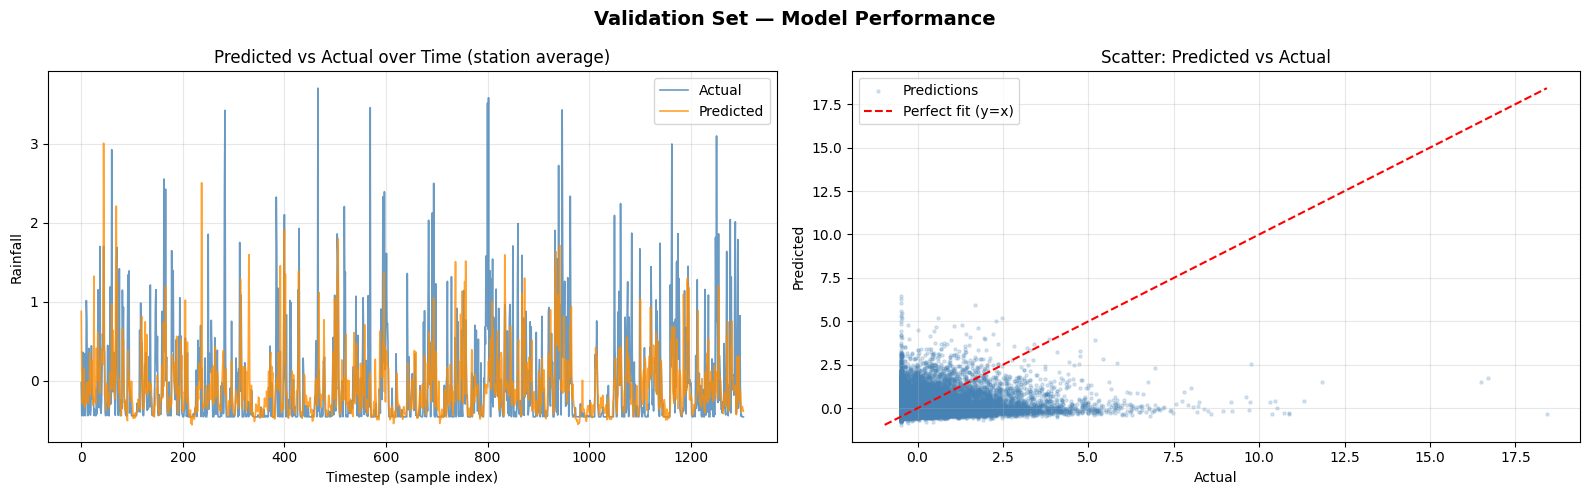

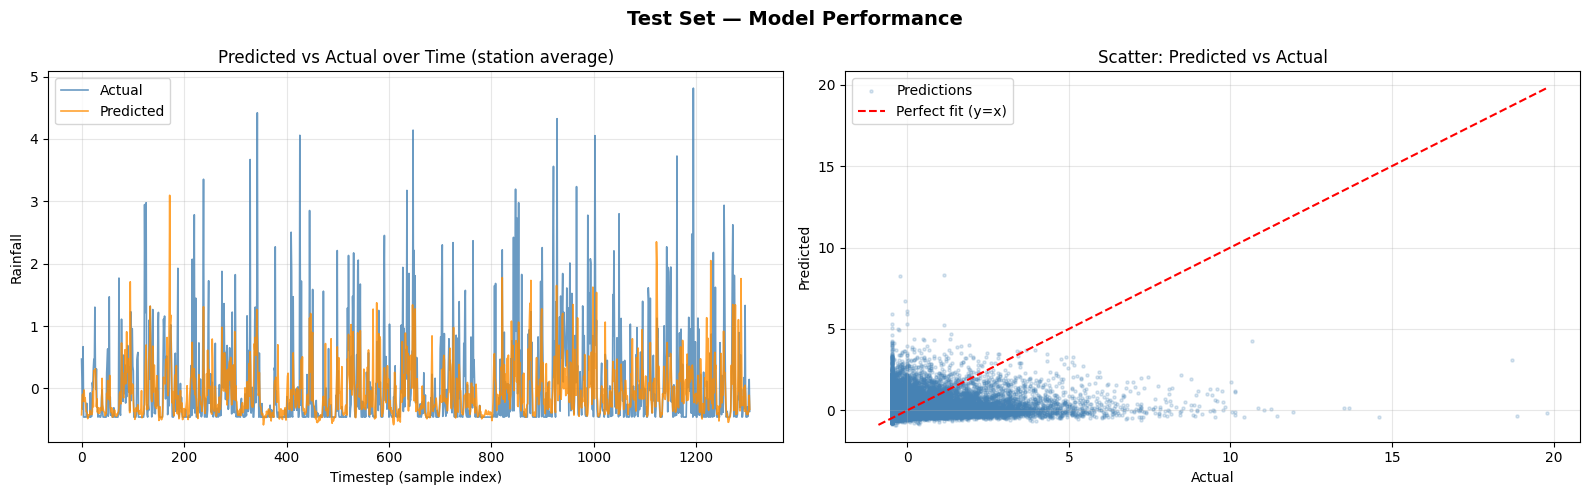

In [27]:
import matplotlib.pyplot as plt

def plot_pred_vs_actual(preds, actuals, split_name):
    """
    Two plots side by side:
      Left  — predicted vs actual averaged across all stations over time
      Right — scatter plot of all predictions vs actuals
    """
    # Average across stations → one value per timestep for a clean time series
    pred_mean   = preds.mean(axis=1)    # [n_samples]
    actual_mean = actuals.mean(axis=1)  # [n_samples]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{split_name} Set — Model Performance", fontsize=14, fontweight="bold")

    # ── Left: Time series ─────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(actual_mean, label="Actual",    color="steelblue",  alpha=0.8, linewidth=1.2)
    ax.plot(pred_mean,   label="Predicted", color="darkorange", alpha=0.8, linewidth=1.2)
    ax.set_title("Predicted vs Actual over Time (station average)")
    ax.set_xlabel("Timestep (sample index)")
    ax.set_ylabel("Rainfall")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Right: Scatter plot ───────────────────────────────────────────────────
    ax = axes[1]
    p_flat = preds.flatten()
    a_flat = actuals.flatten()

    ax.scatter(a_flat, p_flat, alpha=0.2, s=5, color="steelblue", label="Predictions")

    # Draw the perfect-prediction diagonal line y=x
    lims = [min(a_flat.min(), p_flat.min()), max(a_flat.max(), p_flat.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit (y=x)")

    ax.set_title("Scatter: Predicted vs Actual")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_pred_vs_actual(val_preds,  val_actuals,  "Validation")
plot_pred_vs_actual(test_preds, test_actuals, "Test")

In [28]:
# ── You need a list of (lat, lon) per station in the same order as your graph ─
# Replace this with your actual station coordinates list
# Example: station_coords = [(52.01, 4.36), (51.98, 4.40), ...]
# station_coords[i] = (lat, lon) of station i

def plot_error_map(preds, actuals, station_coords, split_name):
    """
    Plots a geographic scatter map where each station is coloured
    by its mean absolute error (MAE) across all timesteps.

    Args:
        preds          : np.array [n_samples, N_STATIONS]
        actuals        : np.array [n_samples, N_STATIONS]
        station_coords : list of (lat, lon) tuples, length = N_STATIONS
        split_name     : string label for the plot title
    """
    # Compute per-station MAE — axis=0 averages over all timesteps
    per_station_mae = np.mean(np.abs(preds - actuals), axis=0)  # [N_STATIONS]

    lats = [c[0] for c in station_coords]   # extract latitudes
    lons = [c[1] for c in station_coords]   # extract longitudes

    fig, ax = plt.subplots(figsize=(9, 7))

    # Scatter each station, colour = its MAE value
    sc = ax.scatter(
        lons, lats,
        c=per_station_mae,      # colour intensity = error magnitude
        cmap="RdYlGn_r",        # red = high error, green = low error
        s=120,                  # marker size
        edgecolors="black",
        linewidths=0.5,
        zorder=3
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Mean Absolute Error (MAE)", fontsize=11)

    ax.set_title(f"{split_name} Set — Per-Station MAE Error Map", fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Also print a ranked table so you can see which stations are worst
    print(f"\n── {split_name} Per-Station MAE (worst → best) ──")
    ranked = sorted(enumerate(per_station_mae), key=lambda x: x[1], reverse=True)
    for rank, (station_idx, mae) in enumerate(ranked, 1):
        lat, lon = station_coords[station_idx]
        print(f"  {rank:2d}. Station {station_idx:3d} | lat {lat:.4f} lon {lon:.4f} | MAE {mae:.4f}")


# ── Plug in your actual station coordinates here ──────────────────────────────
# station_coords = [...]   # your list of (lat, lon) tuples

plot_error_map(val_preds,  val_actuals,  station_coords, "Validation")
plot_error_map(test_preds, test_actuals, station_coords, "Test")

NameError: name 'station_coords' is not defined